In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import UnivariateSpline
data_path = './ecg_data/'
file_name = 'v1_ecg_log_2025-12-18_232929.csv'
ecg = pd.read_csv(data_path + file_name)
ecg['time'] = ecg['time'] - ecg['time'].values[0]

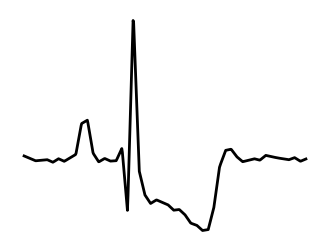

In [8]:
plt.figure(figsize=(4, 3))
ecg_slide = ecg[(ecg['time']<20907)&(ecg['time']>20906)]
t = ecg_slide['time'].to_numpy()
x = ecg_slide['ecg'].to_numpy()
idx_base = np.hstack(
    [
    np.arange(0, 10), 
    np.arange(12, 16),
    np.arange(38, 50),
    ]
)
tb, xb = t[idx_base], x[idx_base]

# s 控制“贴合程度”：s越大越平，越像你画的那条红线
spl = UnivariateSpline(tb, xb, k=3, s=len(tb)*1.0)
baseline = spl(t)
x_corr = x - baseline

# 目标：插到更密，比如每两个原点之间补 10 个点
factor = 10
t_new = np.linspace(t.min(), t.max(), len(t)*factor)
x_new = np.interp(t_new, t, x_corr)

#plt.plot(t, x_corr, 'o', alpha=0.4)   # 原始点
plt.plot(t_new, x_new, color='k', linewidth=2)          # 插值后

ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['bottom'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.set_xticks([])
ax.set_yticks([])
plt.savefig('ecg_v1_plot1.jpg', dpi=500)